# Introduccion

En este proyecto se realizará un análisis exploratorio de datos sobre el catálogo de Netflix.  

El objetivo es analizar diferentes características del contenido disponible, como el tipo de producción, la evolución en el tiempo, los países con mayor producción y la duración de las películas.



## Preguntas de interés

Para este análisis me planteé las siguientes preguntas:

- ¿Predominan las películas o las series en el catálogo de Netflix?

- ¿Cómo ha evolucionado la cantidad de contenido a lo largo de los años?

- ¿Qué países producen mayor cantidad de contenido para Netflix?

- ¿Cuál es la duración promedio de las películas?


In [45]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

url = "https://raw.githubusercontent.com/rodr1r/netflix_dataset/refs/heads/main/netflix_titles.csv"
df = pd.read_csv(url)
df.head()


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


## Exploración inicial del dataset

Primero se realiza una exploración general del dataset para conocer su estructura, cantidad de registros, tipos de datos y posibles valores faltantes.

In [46]:
df.shape
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


,0
show_id,0
type,0
title,0
director,2634
cast,825
country,831
date_added,10
release_year,0
rating,4
duration,3


## Limpieza y preparación de datos

Se eliminan espacios en la columna de fechas y se convierte a formato datetime.  
También se extrae el valor numérico de la duración para poder realizar análisis posteriores.

In [47]:
df["date_added"] = df["date_added"].astype(str).str.strip()

df["date_added"] = pd.to_datetime(df["date_added"], errors="coerce")

df["duration_int"] = (
    df["duration"]
    .astype(str)
    .str.extract(r"(\d+)")[0]
    .astype(float)
)

df["duration_int"] = pd.to_numeric(df["duration_int"][0], errors="coerce")

## Distribución de tipo de contenido

En este gráfico se analiza la proporción entre películas y series dentro del catálogo de Netflix.

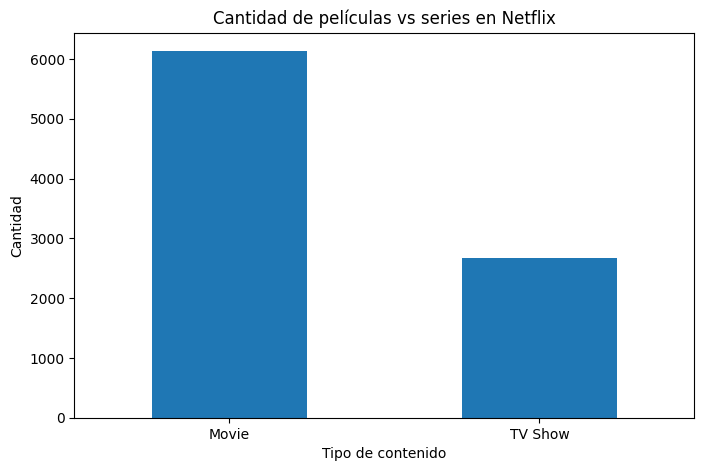

In [48]:
plt.figure(figsize=(8,5))

df["type"].value_counts().plot(kind="bar")

plt.title("Cantidad de películas vs series en Netflix")
plt.xlabel("Tipo de contenido")
plt.ylabel("Cantidad")
plt.xticks(rotation=0)

plt.show()

## Evolución del contenido a lo largo del tiempo

Este gráfico muestra cómo ha cambiado la cantidad de títulos producidos a lo largo de los años.

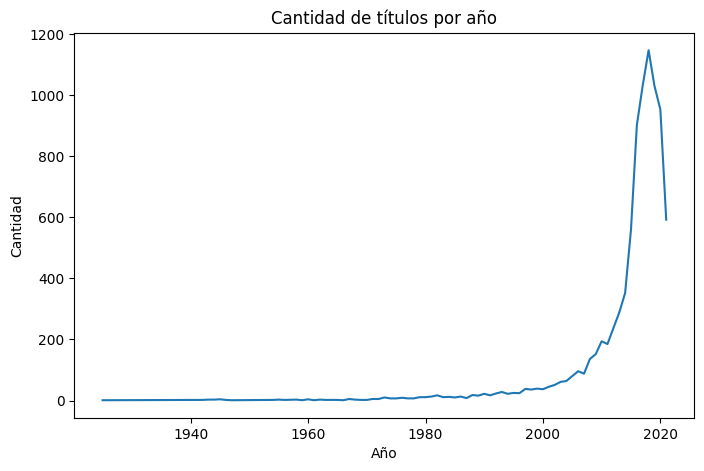

In [49]:
plt.figure(figsize=(8,5))

df.groupby("release_year").size().plot()

plt.title("Cantidad de títulos por año")
plt.xlabel("Año")
plt.ylabel("Cantidad")

plt.show()

## Países con mayor cantidad de contenido

Aquí se observan los países que producen mayor cantidad de contenido dentro del catálogo de Netflix.

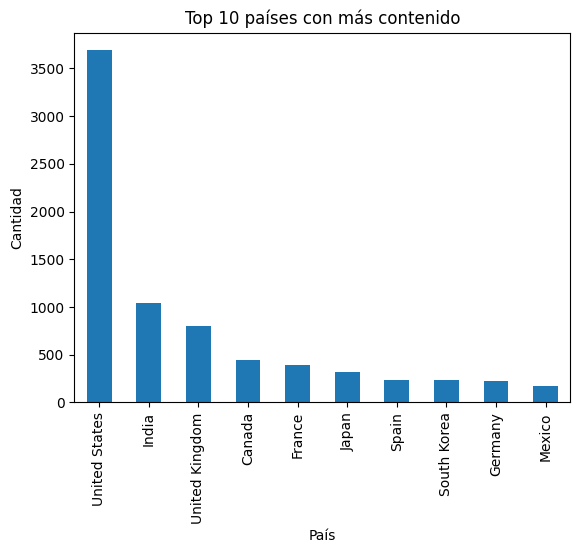

In [50]:
df["country"].str.split(", ").explode().value_counts().head(10).plot(kind="bar")

plt.title("Top 10 países con más contenido")
plt.xlabel("País")
plt.ylabel("Cantidad")
plt.show()

## Géneros más frecuentes en el catálogo

En esta visualización se analizan los géneros más comunes dentro del catálogo de Netflix.  
Esto permite identificar qué tipo de contenido predomina en la plataforma.

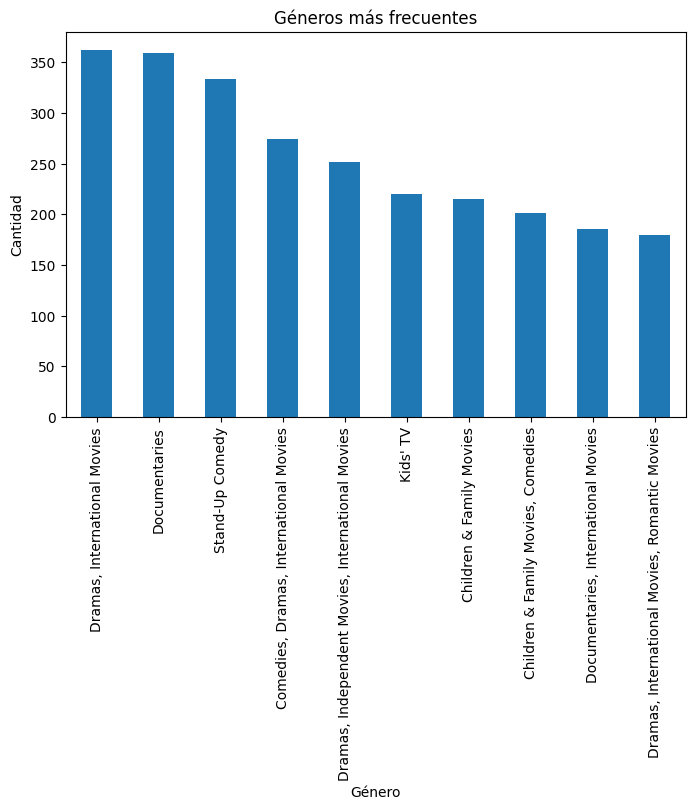

In [51]:
plt.figure(figsize=(8,5))

df["listed_in"].value_counts().head(10).plot(kind="bar")

plt.title("Géneros más frecuentes")
plt.xlabel("Género")
plt.ylabel("Cantidad")

plt.show()

In [52]:
df[df["type"]=="Movie"]["duration_int"].mean()

np.float64(90.0)

## Modelado predictivo

En esta sección se construirá un modelo de clasificación para predecir si un título corresponde a una película o a una serie.

Se utilizarán variables numéricas del dataset y se aplicará un modelo de regresión logística.

In [53]:

df_model = df[["type", "release_year", "duration_int"]].dropna()

df_model["type"] = df_model["type"].map({
    "Movie": 0,
    "TV Show": 1
})

df_model.head()

,type,release_year,duration_int
0,0,2020,90.0
1,1,2021,90.0
2,1,2021,90.0
3,1,2021,90.0
4,1,2021,90.0


## Selección de variables

Se seleccionaron las variables release_year y duration_int por ser numéricas y relevantes para el análisis.

Estas variables permiten diferenciar entre películas y series.

In [54]:
X = df_model[["release_year", "duration_int"]]
y = df_model["type"]

In [55]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [56]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()
model.fit(X_train, y_train)

LogisticRegression()

In [57]:
y_pred = model.predict(X_test)

In [60]:
from sklearn.metrics import accuracy_score, classification_report

print(classification_report(y_test, y_pred, zero_division=0))
print("Accuracy:", accuracy)

print("\nReporte de clasificación:")
print(classification_report(y_test, y_pred, zero_division=0))

              precision    recall  f1-score   support

           0       0.69      1.00      0.82      1214
           1       0.00      0.00      0.00       548

    accuracy                           0.69      1762
   macro avg       0.34      0.50      0.41      1762
weighted avg       0.47      0.69      0.56      1762

Accuracy: 0.6889897843359818

Reporte de clasificación:
              precision    recall  f1-score   support

           0       0.69      1.00      0.82      1214
           1       0.00      0.00      0.00       548

    accuracy                           0.69      1762
   macro avg       0.34      0.50      0.41      1762
weighted avg       0.47      0.69      0.56      1762



## Conclusiones finales

Se desarrolló un modelo de clasificación para predecir si un título corresponde a una película o a una serie.

El modelo obtuvo una accuracy de 0.68, lo que indica que tiene una capacidad aceptable de predicción, aunque aún puede mejorarse incorporando más variables.

Las variables utilizadas fueron el año de lanzamiento y la duración, lo que sugiere que estas características influyen en el tipo de contenido.

El modelo podría mejorar incorporando más variables como género o país.

Este trabajo permitió aplicar técnicas de análisis de datos y modelado predictivo sobre un dataset real.